# Unsupervised — what structure does the data actually have?

The supervised arms assume pH 5/6/7/8 are four separable groups in colour space.
This tests that assumption with the labels held out, using them only afterwards
to score what the clustering found.

**The central question:** do clusters track pH, or do they track degradation
*time*? If time dominates, a per-image pH classifier is fighting a confound.

In [1]:
import csv, warnings
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
warnings.filterwarnings("ignore"); plt.rcParams["figure.dpi"]=110
SEED=42

rows=list(csv.DictReader(open("preprocessing/splits.csv")))
X=np.load("supervised/_features.npz")["X"]
y_ph=np.array([int(r["pH"]) for r in rows])
hour=np.array([int(r["hour"]) for r in rows])
well=np.array([f'{r["pH"]}_{r["well"]}' for r in rows])
prep=make_pipeline(VarianceThreshold(1e-8),StandardScaler())
Xs=prep.fit_transform(X)
print(f"{X.shape[0]} images | {X.shape[1]} raw bins -> {Xs.shape[1]} live features")

2091 images | 512 raw bins -> 169 live features


## PCA — colour variance is not low-dimensional

PC1 0.103 | PC2 0.074 | PC1+2 0.177 | 94 PCs for 90% variance


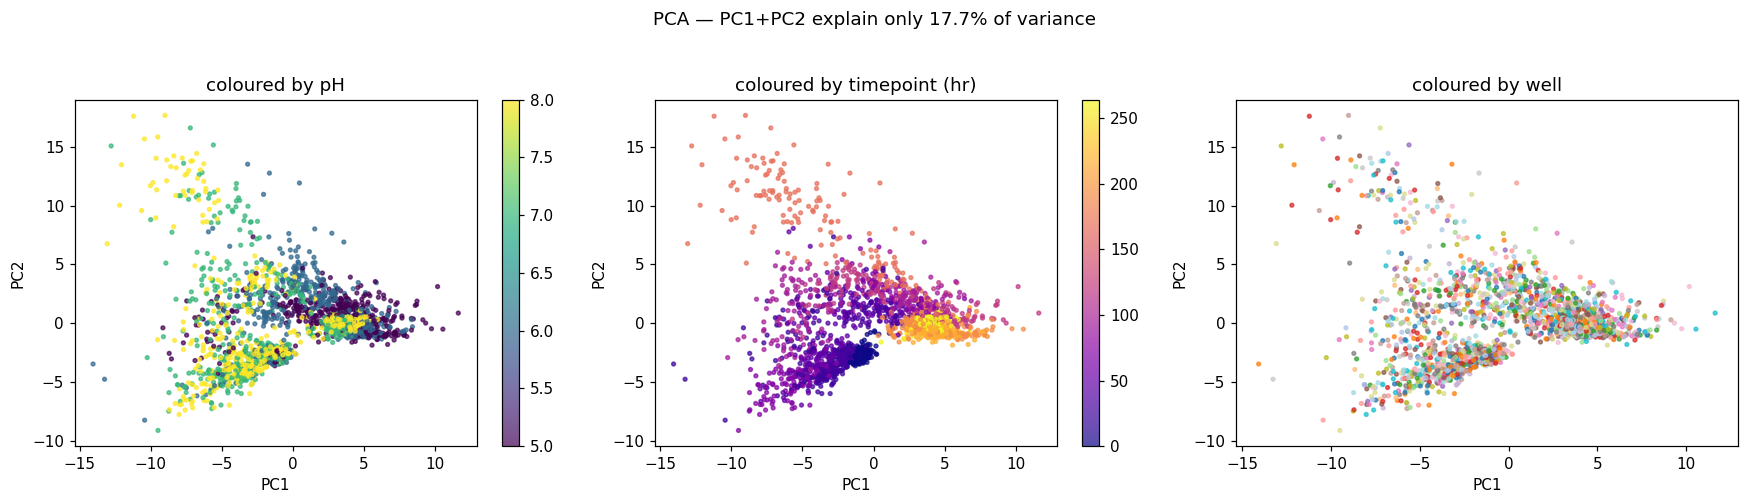

The time panel shows visible banding; the pH panel does not.


In [2]:
pca=PCA(random_state=SEED).fit(Xs)
cum=np.cumsum(pca.explained_variance_ratio_)
n90=int(np.searchsorted(cum,0.90)+1)
print(f"PC1 {pca.explained_variance_ratio_[0]:.3f} | PC2 {pca.explained_variance_ratio_[1]:.3f} "
      f"| PC1+2 {cum[1]:.3f} | {n90} PCs for 90% variance")
Xp=PCA(n_components=n90,random_state=SEED).fit_transform(Xs)
P2=Xp[:,:2]

fig,ax=plt.subplots(1,3,figsize=(16,4.4))
for a,(lab,title,cmap) in zip(ax,[(y_ph,"coloured by pH","viridis"),
                                  (hour,"coloured by timepoint (hr)","plasma"),
                                  (np.array([hash(w)%20 for w in well]),"coloured by well","tab20")]):
    sc=a.scatter(P2[:,0],P2[:,1],c=lab,s=6,cmap=cmap,alpha=.7)
    a.set_title(title); a.set_xlabel("PC1"); a.set_ylabel("PC2")
    if title!="coloured by well": plt.colorbar(sc,ax=a)
plt.suptitle(f"PCA — PC1+PC2 explain only {cum[1]*100:.1f}% of variance",y=1.03)
plt.tight_layout(); plt.show()
print("The time panel shows visible banding; the pH panel does not.")

## What do the clusters track?

k-means with k=4, scored against three candidate groupings. Time is binned into
4 so the comparison with k=4 is fair.

  vs pH                     ARI=+0.077  NMI=0.089
  vs timepoint (4 bins)     ARI=+0.334  NMI=0.409
  vs timepoint (all 11)     ARI=+0.160  NMI=0.359
  vs well                   ARI=+0.000  NMI=0.043


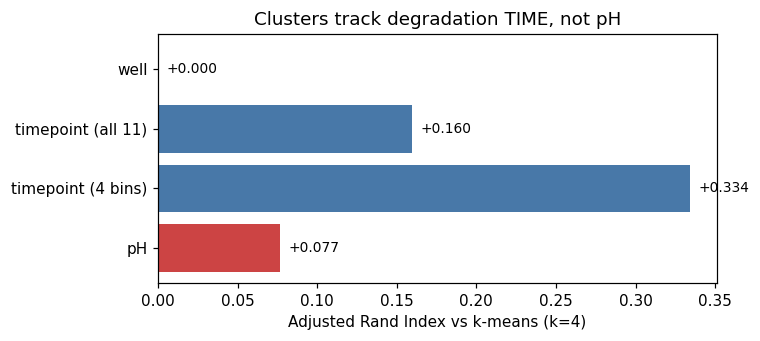

In [3]:
hour_bin=np.digitize(hour,np.quantile(hour,[.25,.5,.75]))
km=KMeans(4,n_init=20,random_state=SEED).fit(Xp)
groupings={"pH":y_ph,"timepoint (4 bins)":hour_bin,"timepoint (all 11)":hour,"well":well}
scores={n:(adjusted_rand_score(g,km.labels_),normalized_mutual_info_score(g,km.labels_))
        for n,g in groupings.items()}
for n,(a,m) in scores.items(): print(f"  vs {n:22s} ARI={a:+.3f}  NMI={m:.3f}")

fig,ax=plt.subplots(figsize=(7,3.2))
ns=list(scores); ax.barh(ns,[scores[n][0] for n in ns],
        color=["#c44" if n=="pH" else "#4878a8" for n in ns])
ax.set_xlabel("Adjusted Rand Index vs k-means (k=4)")
ax.set_title("Clusters track degradation TIME, not pH")
for i,n in enumerate(ns): ax.text(scores[n][0]+.005,i,f"{scores[n][0]:+.3f}",va="center",fontsize=9)
plt.tight_layout(); plt.show()

In [4]:
print("Reproduced across algorithms:\n")
for name,lab in [("k-means",km.labels_),
                 ("GaussianMixture",GaussianMixture(4,random_state=SEED,n_init=5).fit_predict(Xp)),
                 ("Agglomerative(ward)",AgglomerativeClustering(4).fit_predict(Xp))]:
    print(f"  {name:22s} ARI(pH)={adjusted_rand_score(y_ph,lab):+.3f}   "
          f"ARI(time)={adjusted_rand_score(hour_bin,lab):+.3f}")

Reproduced across algorithms:



  k-means                ARI(pH)=+0.077   ARI(time)=+0.334
  GaussianMixture        ARI(pH)=+0.073   ARI(time)=+0.349
  Agglomerative(ward)    ARI(pH)=+0.070   ARI(time)=+0.352


## Is 4 even the natural number of groups?

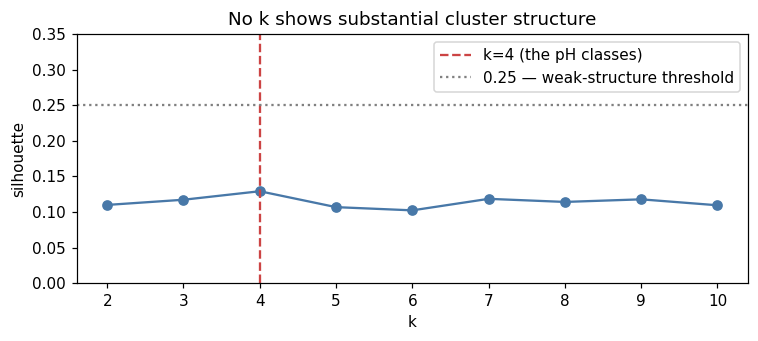

{2: 0.11, 3: 0.117, 4: 0.129, 5: 0.107, 6: 0.102, 7: 0.119, 8: 0.114, 9: 0.118, 10: 0.11}
peak at k=4, but every value is far below 0.25:
the data is closer to one continuous manifold than four discrete blobs,
which is chemically sensible - pH is a continuum.


In [5]:
sil={k:float(silhouette_score(Xp,KMeans(k,n_init=10,random_state=SEED).fit_predict(Xp)))
     for k in range(2,11)}
plt.figure(figsize=(7,3.2))
plt.plot(list(sil),list(sil.values()),"o-",color="#4878a8")
plt.axvline(4,ls="--",c="#c44",label="k=4 (the pH classes)")
plt.axhline(0.25,ls=":",c="grey",label="0.25 — weak-structure threshold")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.ylim(0,0.35)
plt.title("No k shows substantial cluster structure"); plt.legend(); plt.tight_layout(); plt.show()
print({k:round(v,3) for k,v in sil.items()})
print(f"peak at k={max(sil,key=sil.get)}, but every value is far below 0.25:")
print("the data is closer to one continuous manifold than four discrete blobs,")
print("which is chemically sensible - pH is a continuum.")

## Where pH structure does exist — acidic vs alkaline

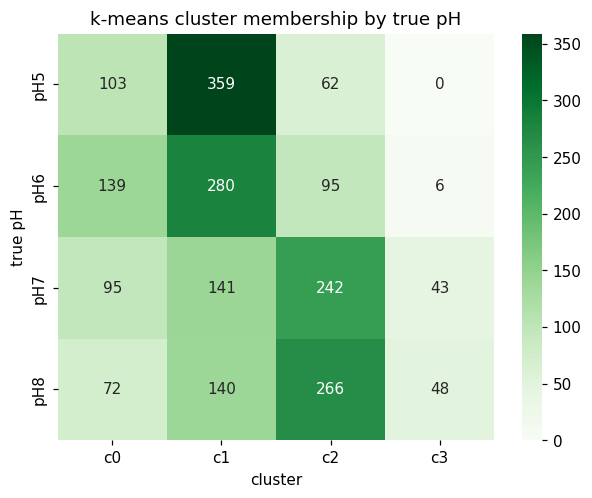

pH5+pH6 concentrate in one cluster, pH7+pH8 in another.
The signal present is ACIDIC vs ALKALINE, not four-way -
mirroring the supervised confusion matrices exactly.


In [6]:
cont=np.array([[int(((y_ph==p)&(km.labels_==c)).sum()) for c in range(4)] for p in (5,6,7,8)])
sns.heatmap(cont,annot=True,fmt="d",cmap="Greens",
            xticklabels=[f"c{c}" for c in range(4)],yticklabels=[f"pH{p}" for p in (5,6,7,8)])
plt.title("k-means cluster membership by true pH"); plt.xlabel("cluster"); plt.ylabel("true pH")
plt.show()
print("pH5+pH6 concentrate in one cluster, pH7+pH8 in another.")
print("The signal present is ACIDIC vs ALKALINE, not four-way -")
print("mirroring the supervised confusion matrices exactly.")

## DBSCAN — density check / preprocessing QA

In [7]:
kd=np.sort(NearestNeighbors(n_neighbors=5).fit(Xp).kneighbors(Xp)[0][:,-1])
eps=float(np.quantile(kd,0.90))
db=DBSCAN(eps=eps,min_samples=5).fit(Xp)
n_noise=int((db.labels_==-1).sum()); n_cl=len(set(db.labels_))-(1 if -1 in db.labels_ else 0)
print(f"eps={eps:.2f} -> {n_cl} cluster(s), {n_noise} noise points ({100*n_noise/len(Xp):.1f}%)")
print("Finding a single cluster is itself the result: no density-separated groups,")
print("consistent with the silhouette scores.")

eps=11.08 -> 1 cluster(s), 145 noise points (6.9%)
Finding a single cluster is itself the result: no density-separated groups,
consistent with the silhouette scores.


---
## What this means

1. **Explains why elapsed time helped** the supervised models (+0.04): time is the
   dominant axis of colour variation.
2. **Sets expectations** — with ARI 0.08 between colour clusters and pH, the
   supervised ceiling around 0.75-0.81 is consistent with the structure present.
3. **Argues for sequence models** — if time dominates single-image colour, model
   the trajectory. See `lstm/`.
4. **Reframes the target** — acidic vs alkaline matches both the cluster structure
   and the clinical question (healthy skin pH 4-6, chronic wound pH 7-8).